![](olympics.jpg)

# How diverse are the countries with the most Olympic wins?

With the 2026 Winter Olympics concluding, Norway took home the most gold medals with an astounding 18. Including its Bronze and Silver, Norway won a total of 41 medals. The rest of the Olympic winners mostly came from European countries. The ten highest countries with the most medals are countries geographically close to Norway. In fact, the United States and Japan are the only countries not located in Europe that placed in the top ten. This striking difference led me to wonder which countries have the most medals from the Olympics, and how geographically diverse this list is.

The lack of geographic diversity also prompted me to consider if there were atheltic diversity within these countries as well, or if one sport tended to win the most medals for each country.

### What are the historically top-performing countries?

To begin the analysis, I calculated which countries have received the most medals since the creation of the Winter Olympics in 1924 from historical data. This data, which can be accessed [here](https://commjhub.asc.upenn.edu/hub/user-redirect/lab/tree/comm3180_S26/comm3180_S26_Blog/posts/003_olympics/data/winter_olympics_medals.csv), is a dataset documenting the athlete, sport, and country of each of the Olympic medals won since 1923.

For this analysis, I took the total number of medals, without regard to if they were gold, silver, or bronze, to determine which country has received the most number of medals. We will be looking at the top ten countries for this analysis. 

In [12]:
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt

In [13]:
wolympics_df = pd.read_csv('data/winter_olympics_medals.csv')

In [14]:
medal_counts = wolympics_df['team'].value_counts()

In [19]:
print(medal_counts.head(10))

team
United States    1142
Canada           1069
Sweden            933
Finland           853
Switzerland       777
Norway            713
Germany           695
Italy             692
Japan             686
France            570
Name: count, dtype: int64


From the inital count above, we can see that the United States has earned the most amount of medals, slightly more than double the amount as France, who has earned the tenth most amount of medals. The range of medals is a vast 570 to 1142. 

In [25]:
top_10=medal_counts.head(10)

Text(0, 0.5, 'Total Medals')

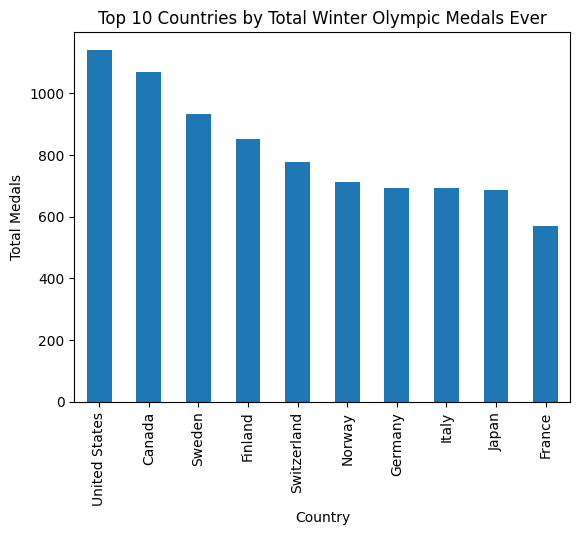

In [26]:
plt.figure()
top_10.plot(kind='bar')
plt.title("Top 10 Countries by Total Winter Olympic Medals Ever")
plt.xlabel("Country")
plt.ylabel("Total Medals")

In the bar graph above, you can see the range of total medals for the top 10 countries. The difference between countries are very small. Specifcally, you can see that the difference between United States and Canada is less than 100 medals. Norway, Germany, Italy, and Japan only differ by less than 30 medals. While the difference between individual countries are smaller, the overall range is high with the difference between France and the United States being over 570. 

### Diversity of Geography

In [57]:
world_gdf = gpd.read_file('data/worldmap.json')
combined_gdf = pd.merge(world_gdf,
                        medal_counts,
                        left_on='name',
                        right_on='team',
                        how='outer')
combined_gdf['count'] = combined_gdf['count'].fillna(0)

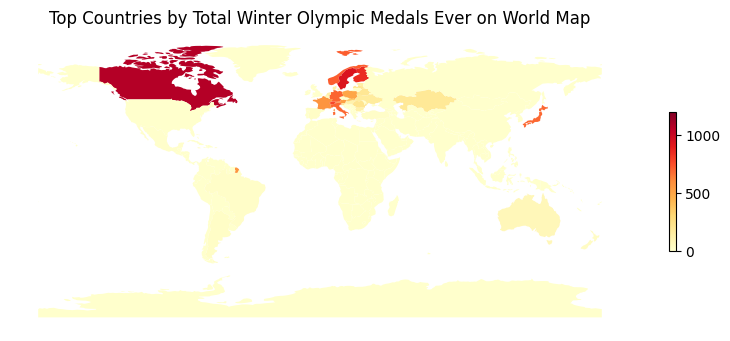

In [58]:
combined_gdf.plot(column='count',
                  legend=True,
                  legend_kwds={
                      'shrink': 0.3,
                  },
                  figsize=(10, 6),
                  vmin=0,
                  vmax=1200,
                  cmap='YlOrRd'
)

plt.axis('off')
plt.title("Top Countries by Total Winter Olympic Medals Ever on World Map")
plt.show()

When looking at the top ten countries on a map, you can clearly see the disproportionate distribution of countries. Most of the countries receiving the most medals are from North America or Europe. Only one country is not from either of these continents, Japan. However, Japan is still a major global power.  

**The list of most accomplishmented countries are not geographically diverse.**

However, the history of the Winter Olympics explains this disproportionate distribution. The first Winter Olympics saw mostly particaption from countries in Europe and North America. Countries in these regions are more equipped for winter sports. For example, sports like skiing and sledding require cold-weather climates that North America and northern European countries are more equipped for.

With winter sports requiring snow, mountains, or general cold seasons, North America and Europe have an advantage explaining the high success rate of these countries in the Olympics. 

Additionally, these countries are also highly industrialized and wealthy nations, which also provide an advantage in training high-performing athletes.

# Diversity of Performance 

I also wanted to analyze whether countries demonstrated diversity in their performance, specifically, where their high medal counts were originating from. For example, were their totals driven primarily by gold medals, or were they spread across gold, silver, and bronze? Additionally, were these medals concentrated in just a few sports, or distributed across a more diverse range of disciplines?

In [48]:
top_10_countries = medal_counts.head(10).index.tolist()
medal_filter = ~wolympics_df['medal'].isna()
top10_filter = wolympics_df['team'].isin(top_10_countries)
top10_medals_df = wolympics_df[medal_filter & top10_filter].groupby(['team', 'medal']).size().unstack()
top10_medals_df = top10_medals_df.reindex(top_10_countries)

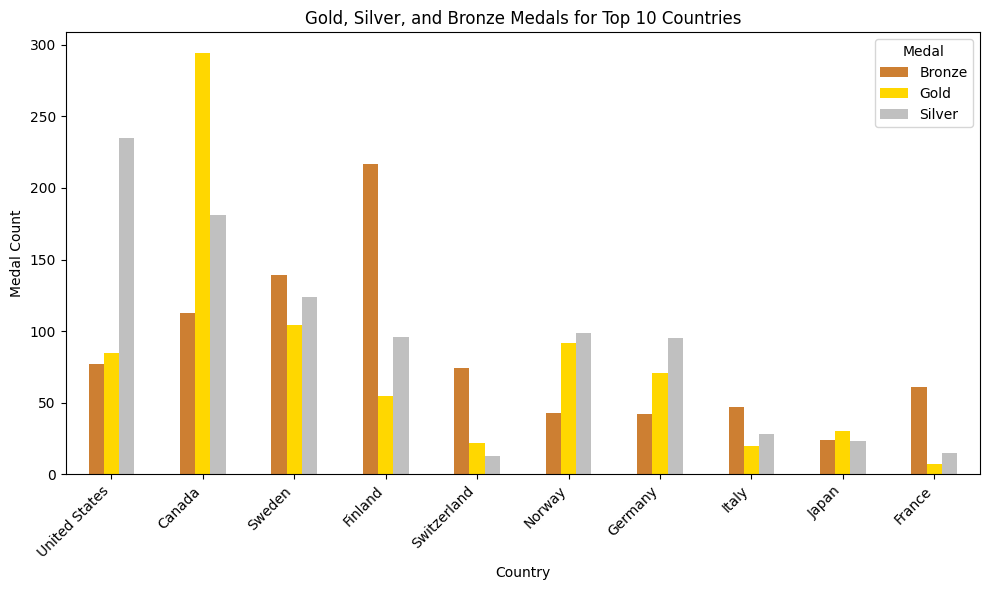

In [49]:
top10_medals_df.plot(kind='bar', 
                     color=['#CD7F32', '#FFD700', '#C0C0C0'],
                     figsize=(10, 6))
plt.title('Gold, Silver, and Bronze Medals for Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Medal Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Medal')
plt.tight_layout()
plt.show()

The countries have a diverse collection of gold, silver, and bronze medals. However, the United States has a signifcant majortiy of silver medals, while Canada has a large majortiy of gold medals. It suggest that, despite the United States having the most medals, Canada may have more higher-preforming athletes. Finland also has a high portion of bronze medals, another country with a less diverse distribution. 

The rest of the countries have a more diverse and equal distribution of gold, silver, and bronze medals. 

I then conducted an analysis to see the diversity of sports that countries earned medals from. I created a pie chart for each of the 10 countries to see what sports they earned their medals from.

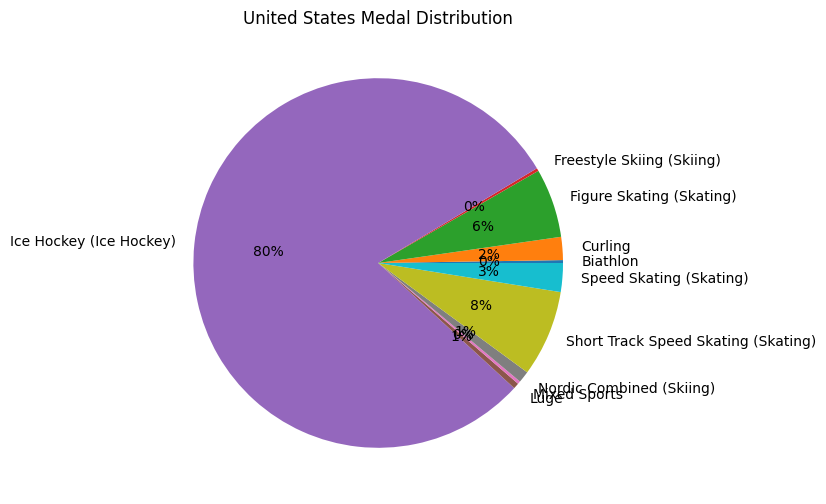

In [66]:
country_data = wolympics_df[medal_filter & (wolympics_df['team'] == 'United States')].groupby('discipline').size()
plt.figure(figsize=(6, 6))
plt.pie(country_data.values, labels=country_data.index, autopct='%1.0f%%')
plt.title('United States Medal Distribution')
plt.show()

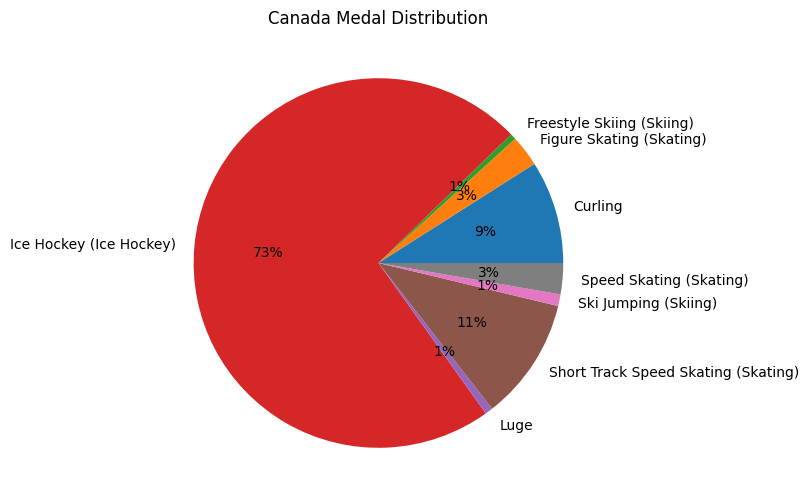

In [67]:
country_data = wolympics_df[medal_filter & (wolympics_df['team'] == 'Canada')].groupby('discipline').size()
plt.figure(figsize=(6, 6))
plt.pie(country_data.values, labels=country_data.index, autopct='%1.0f%%')
plt.title('Canada Medal Distribution')
plt.show()

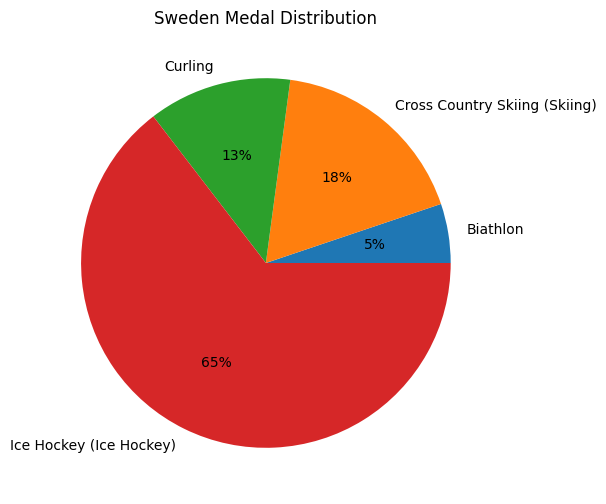

In [68]:
country_data = wolympics_df[medal_filter & (wolympics_df['team'] == 'Sweden')].groupby('discipline').size()
plt.figure(figsize=(6, 6))
plt.pie(country_data.values, labels=country_data.index, autopct='%1.0f%%')
plt.title('Sweden Medal Distribution')
plt.show()

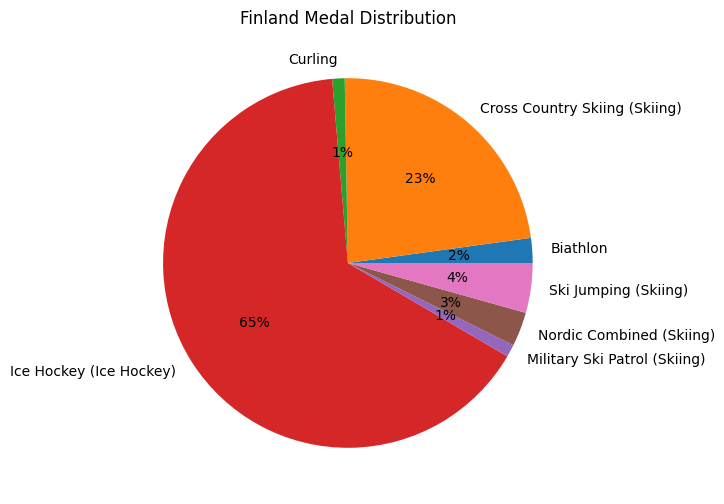

In [69]:
country_data = wolympics_df[medal_filter & (wolympics_df['team'] == 'Finland')].groupby('discipline').size()
plt.figure(figsize=(6, 6))
plt.pie(country_data.values, labels=country_data.index, autopct='%1.0f%%')
plt.title('Finland Medal Distribution')
plt.show()

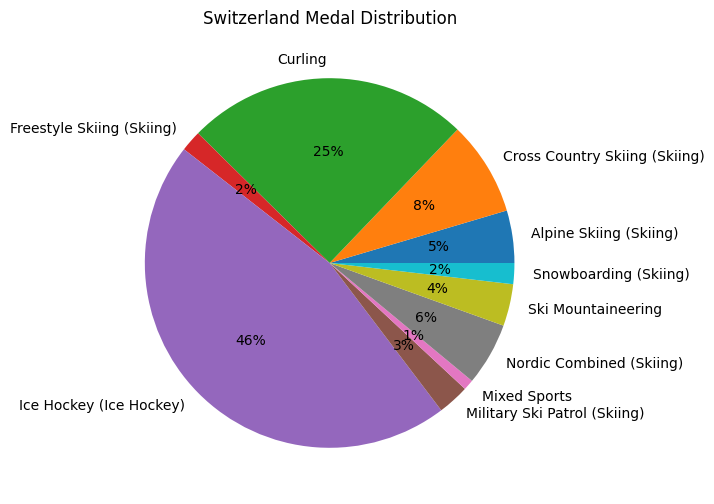

In [70]:
country_data = wolympics_df[medal_filter & (wolympics_df['team'] == 'Switzerland')].groupby('discipline').size()
plt.figure(figsize=(6, 6))
plt.pie(country_data.values, labels=country_data.index, autopct='%1.0f%%')
plt.title('Switzerland Medal Distribution')
plt.show()

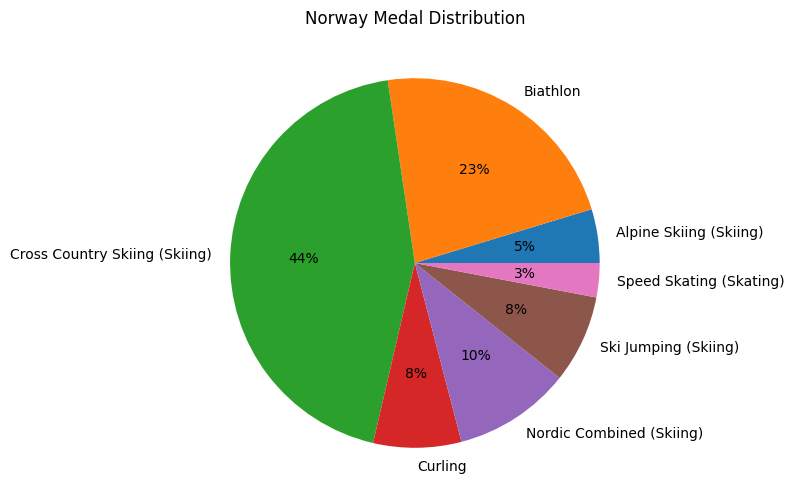

In [71]:
country_data = wolympics_df[medal_filter & (wolympics_df['team'] == 'Norway')].groupby('discipline').size()
plt.figure(figsize=(6, 6))
plt.pie(country_data.values, labels=country_data.index, autopct='%1.0f%%')
plt.title('Norway Medal Distribution')
plt.show()

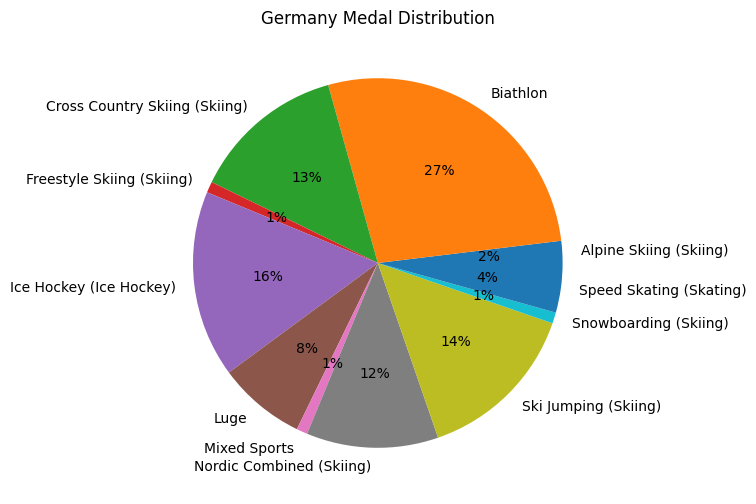

In [72]:
country_data = wolympics_df[medal_filter & (wolympics_df['team'] == 'Germany')].groupby('discipline').size()
plt.figure(figsize=(6, 6))
plt.pie(country_data.values, labels=country_data.index, autopct='%1.0f%%')
plt.title('Germany Medal Distribution')
plt.show()

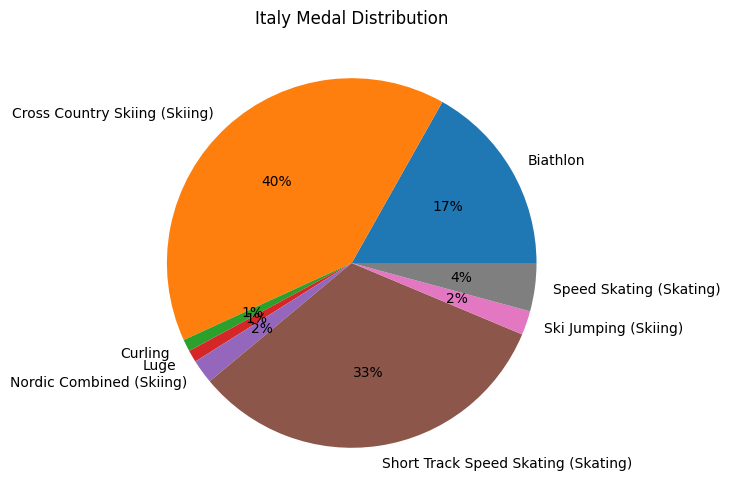

In [73]:
country_data = wolympics_df[medal_filter & (wolympics_df['team'] == 'Italy')].groupby('discipline').size()
plt.figure(figsize=(6, 6))
plt.pie(country_data.values, labels=country_data.index, autopct='%1.0f%%')
plt.title('Italy Medal Distribution')
plt.show()

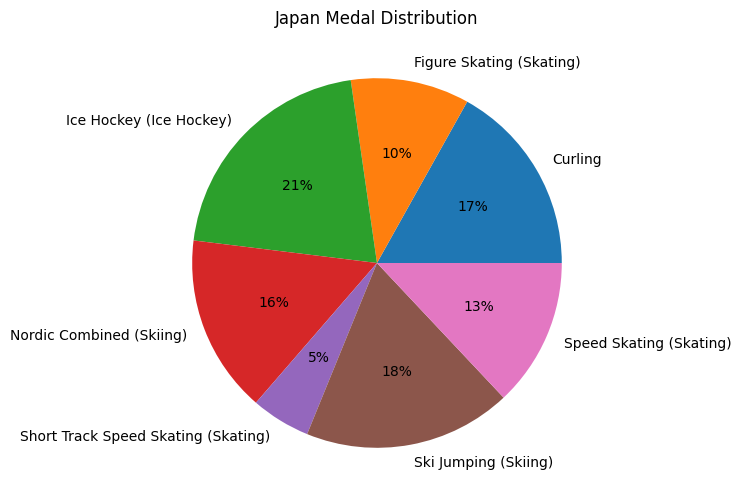

In [74]:
country_data = wolympics_df[medal_filter & (wolympics_df['team'] == 'Japan')].groupby('discipline').size()
plt.figure(figsize=(6, 6))
plt.pie(country_data.values, labels=country_data.index, autopct='%1.0f%%')
plt.title('Japan Medal Distribution')
plt.show()

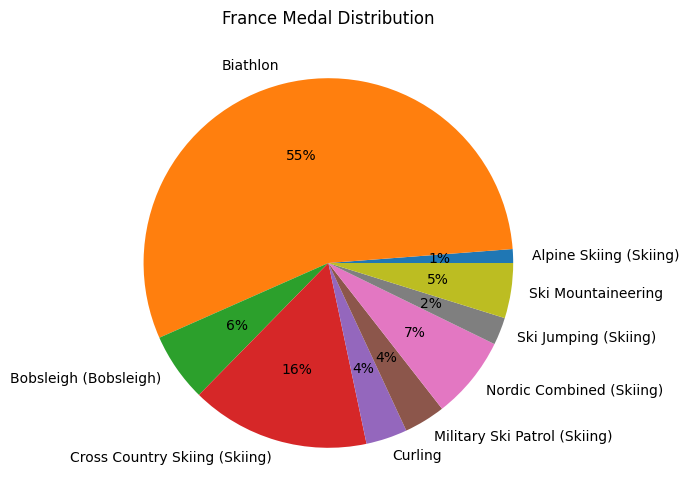

In [75]:
country_data = wolympics_df[medal_filter & (wolympics_df['team'] == 'France')].groupby('discipline').size()
plt.figure(figsize=(6, 6))
plt.pie(country_data.values, labels=country_data.index, autopct='%1.0f%%')
plt.title('France Medal Distribution')
plt.show()

The pie charts above suggest that ice hockey is the most prominent sport among these countries, as the top five countries — the United States, Canada, Sweden, Finland, and Switzerland — all have a high majority of their medals coming from ice hockey. The remaining countries, with the exception of France, which has a high majority of its medals coming from biathlon, show a more diverse and evenly distributed range of sports.